In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_train = pd.read_csv("./dataset/train.csv")
df_fullfilment = pd.read_csv("./dataset/fulfilment_center_info.csv")
df_meal = pd.read_csv("./dataset/meal_info.csv")

In [4]:
print(f"Train data: {df_train.shape}")
print(f"Fullfilment_center_info data: {df_fullfilment.shape}")
print(f"Meal_info data: {df_meal.shape}")

Train data: (456548, 9)
Fullfilment_center_info data: (77, 5)
Meal_info data: (51, 3)


In [5]:
df_train.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [6]:
df_fullfilment.head()

,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [7]:
df_meal.head()

,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


In [8]:
df_train.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000


In [9]:
df_train.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64

In [10]:
df_meal["category"].unique(), df_meal["cuisine"].unique()

(<StringArray>
 [   'Beverages',       'Extras',         'Soup', 'Other Snacks',
         'Salad',    'Rice Bowl',     'Starters',     'Sandwich',
         'Pasta',       'Desert',      'Biryani',        'Pizza',
          'Fish',      'Seafood']
 Length: 14, dtype: str,
 <StringArray>
 ['Thai', 'Indian', 'Italian', 'Continental']
 Length: 4, dtype: str)

In [11]:
print(df_train.shape)
df = df_train.merge(df_fullfilment, on="center_id", how='left')
df = df.merge(df_meal, on="meal_id", how="left")
print(df.shape)

(456548, 9)
(456548, 15)


In [12]:
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian


In [13]:
df_temp = df.groupby(by="category").agg({"cuisine": "nunique"}).reset_index()
df_temp

,category,cuisine
0,Beverages,4
1,Biryani,1
2,Desert,1
3,Extras,1
4,Fish,1
5,Other Snacks,1
6,Pasta,1
7,Pizza,1
8,Rice Bowl,1
9,Salad,1


### Observation
* Other than 'Beverages', all other categories are unique to their cuisine

In [14]:
df_temp = df.groupby(by="center_id").agg({"cuisine": "nunique"}).reset_index().sort_values('cuisine')
df_temp['cuisine'].min(), df_temp['cuisine'].max(), df_temp['cuisine'].mean(), df_temp['cuisine'].median()

(np.int64(4), np.int64(4), np.float64(4.0), np.float64(4.0))

In [15]:
df_temp = df.groupby(by="center_id").agg({"category": "nunique"}).reset_index().sort_values('category')
df_temp['category'].min(), df_temp['category'].max(), df_temp['category'].mean(), df_temp['category'].median()

(np.int64(11), np.int64(14), np.float64(12.766233766233766), np.float64(12.0))

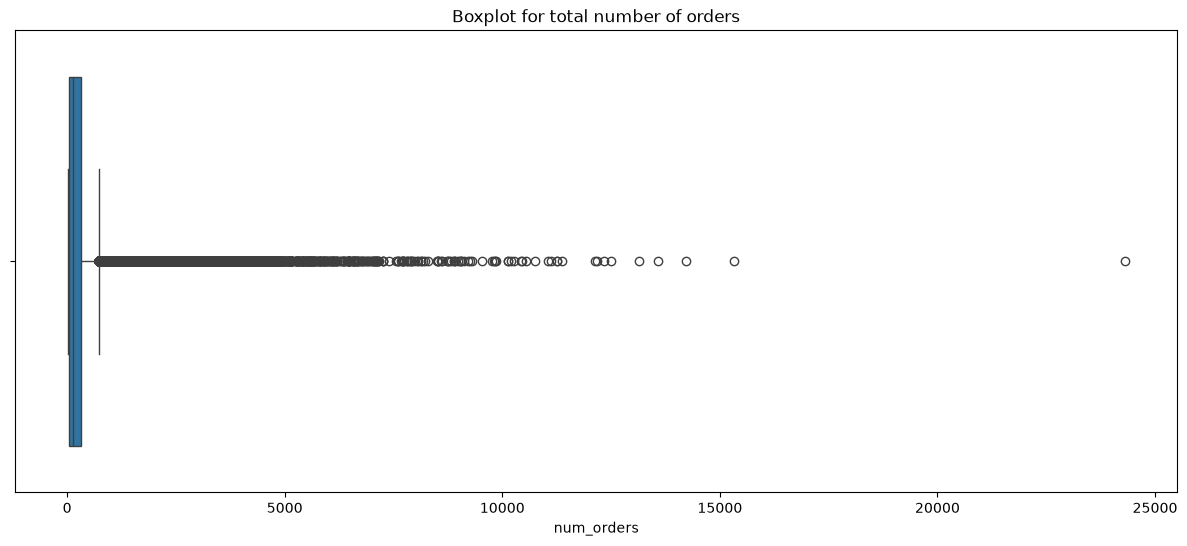

In [16]:
plt.figure(figsize=(15,6))
sns.boxplot(data = df, x="num_orders")
plt.title("Boxplot for total number of orders")
plt.show()

In [17]:
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian


In [36]:
df['center_id'].nunique(), df['meal_id'].nunique(), df['city_code'].nunique(), df['region_code'].nunique(), len(df), df['week'].max()

(77, 51, 51, 8, 456548, np.int64(145))

In [73]:
weeks = range(1, df['week'].max()+1)
df_forecastibility = (
    df.groupby(['center_id', 'meal_id'])
    .apply(lambda x: pd.Series({
        'total_obs': len(weeks),
        'non_zero_obs': (x['num_orders'] >0).sum(),
        'ADI': (len(weeks)/(x['num_orders']>0).sum() if (x['num_orders']>0).any() else None),
        'CV2': (x.loc[x['num_orders'] > 0, 'num_orders'].std()/ x.loc[x['num_orders'] > 0, 'num_orders'].mean()) **2
    })).reset_index()
)
df_forecastibility['SBC'] = np.select(
    [
        (df_forecastibility['ADI'] < 1.32) & (df_forecastibility['CV2'] < 0.49),
        (df_forecastibility['ADI'] >= 1.32) & (df_forecastibility['CV2'] < 0.49),
        (df_forecastibility['ADI'] < 1.32) & (df_forecastibility['CV2'] >= 0.49),
        (df_forecastibility['ADI'] >= 1.32) & (df_forecastibility['CV2'] >= 0.49)
    ],
    ['Smooth', 'Intermittent', 'Erratic', 'Lumpy'],
    default='NA'
)
df_forecastibility.head()

,center_id,meal_id,total_obs,non_zero_obs,ADI,CV2,SBC
0,10,1062,145.0,145.0,1.000000,0.075145,Smooth
1,10,1109,145.0,145.0,1.000000,0.171756,Smooth
2,10,1198,145.0,145.0,1.000000,0.167105,Smooth
3,10,1207,145.0,144.0,1.006944,0.670863,Erratic
4,10,1216,145.0,143.0,1.013986,0.161993,Smooth


In [74]:
df_forecastibility.groupby(by='SBC').agg({'non_zero_obs': ['count', 'min', 'max', 'mean', 'median'] }).round(1)

non_zero_obs                            
                    count    min    max   mean median
SBC                                                  
Erratic              1221  110.0  145.0  137.6  143.0
Intermittent          412    3.0  109.0   70.0   77.0
Lumpy                 199    3.0  109.0   77.7   83.0
NA                      3    1.0    1.0    1.0    1.0
Smooth               1762  110.0  145.0  138.6  144.0

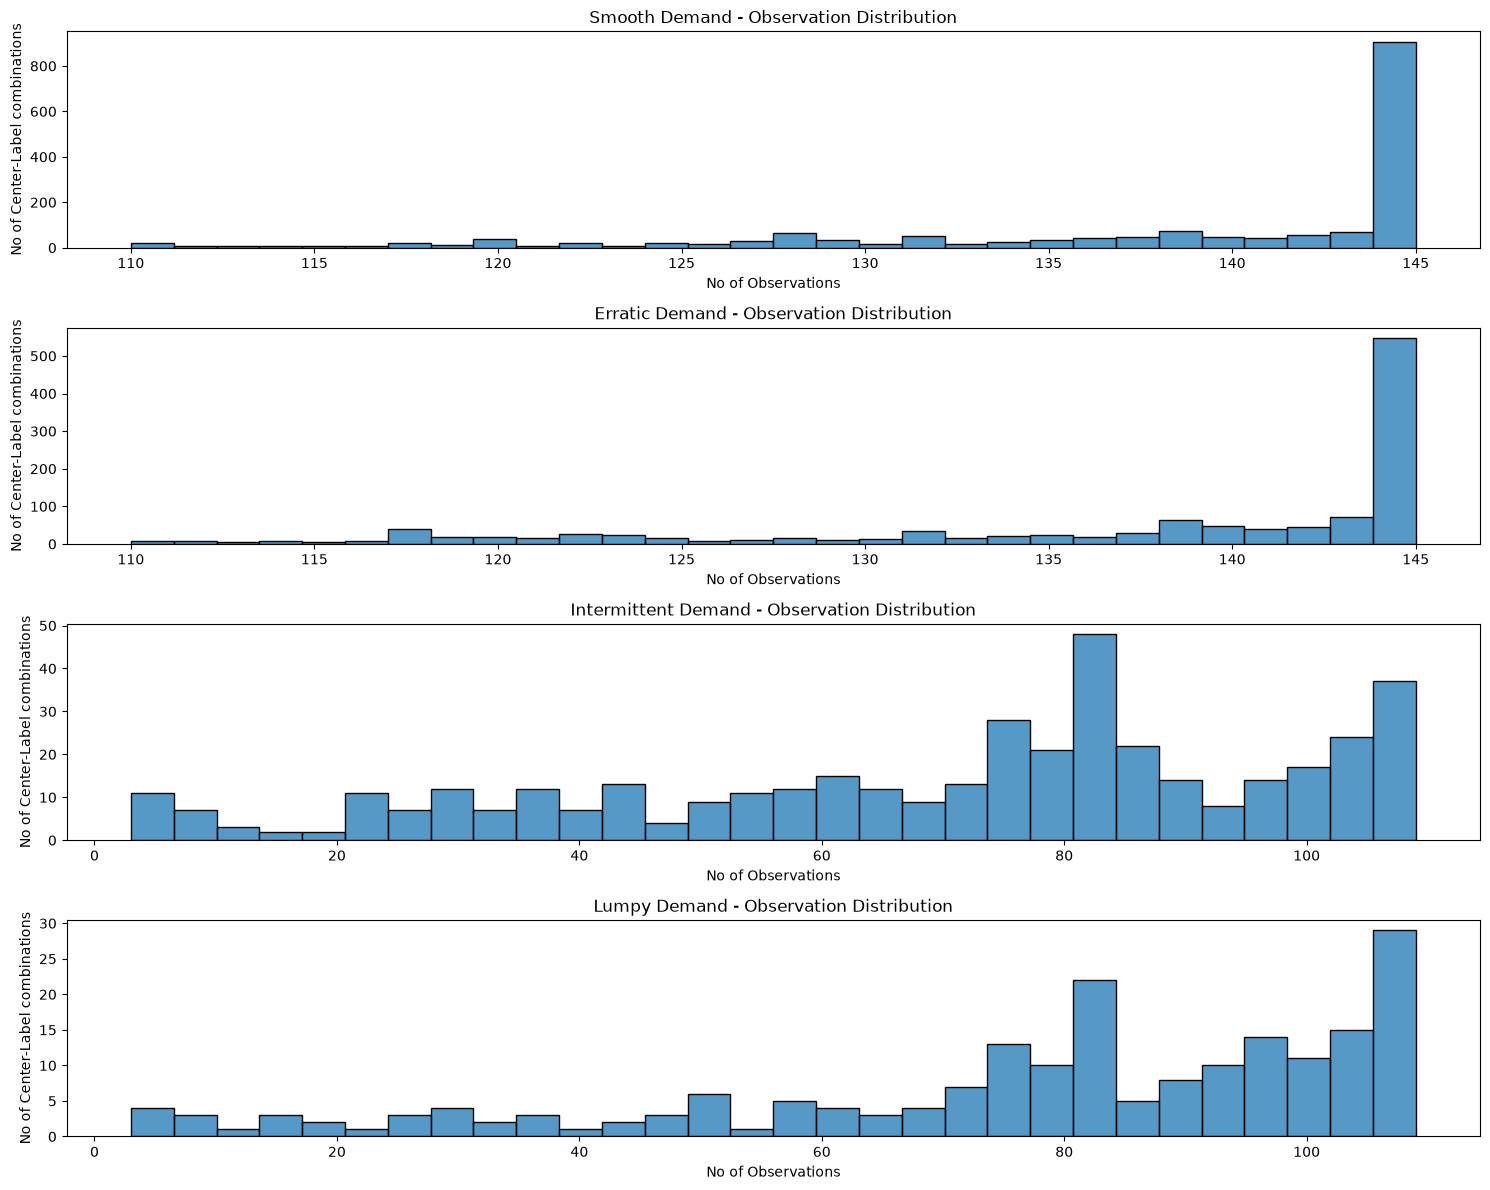

In [75]:
fig, ax = plt.subplots(nrows=4, figsize=(15, 12))
for i, sbc in enumerate(['Smooth', 'Erratic', 'Intermittent', 'Lumpy']):
    data = df_forecastibility[df_forecastibility['SBC'] == sbc]
    sns.histplot(data=data, x='non_zero_obs', bins=30,  label="Non-zero Observations", ax=ax[i])
    ax[i].set_title(f"{sbc} Demand - Observation Distribution")
    ax[i].set_xlabel("No of Observations")
    ax[i].set_ylabel("No of Center-Label combinations")
    # ax[i].grid(axis='y', aplpha=0.2)
plt.tight_layout()
plt.show()

In [76]:
df_forecastibility.to_csv("./mywork/forecastibility.csv", index=False)